FAKE JOB POSTONG CLASSIFIER

Project Description

This project detects whether a job posting is real or fake using Machine Learning. It analyzes the job title, company profile, description, requirements, and benefits to classify job advertisements. Text data is converted into numerical features using TF-IDF, and a Random Forest Classifier is trained to make predictions

0 = Real Job
1 = Fake Job

Model Used

Random Forest Classifier

The model used in this project is the Random Forest Classifier, which is an ensemble machine learning algorithm.

It consists of multiple decision trees, and each tree makes its own prediction. The final prediction is determined by majority voting among all the trees

IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from wordcloud import WordCloud
import joblib

LOADING DATASET

In [5]:
with open("fake_job_postings.csv", "r", errors="ignore") as f:
    for i in range(10):
        print(f.readline())

job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent

1,Marketing Intern,"US, NY, New York",Marketing,,"We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard 

In [6]:
import os

print("File size:", os.path.getsize("fake_job_postings.csv"), "bytes")

File size: 6291456 bytes


In [7]:
import pandas as pd

df = pd.read_csv(
    "fake_job_postings.csv",
    header=None,
    on_bad_lines="skip",
    engine="python"
)

df.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
1,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
2,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
3,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
4,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0


In [8]:
print(df.shape)

(2644, 18)


In [9]:
print(df.columns)

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], dtype='int64')


In [10]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
1,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
2,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
3,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
4,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0


In [11]:
df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [12]:
print (df.columns)

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object', name=0)


Missing Values

In [13]:
df.isnull().sum()

,0
0,
job_id,0
title,0
location,38
department,1670
salary_range,2225
company_profile,534
description,0
requirements,378
benefits,1060


Fill Missing Values

In [14]:
df=df.fillna("")

Check Fake vs Real Jobs

In [16]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,2564
1,79


Plot Fake vs Real Jobs

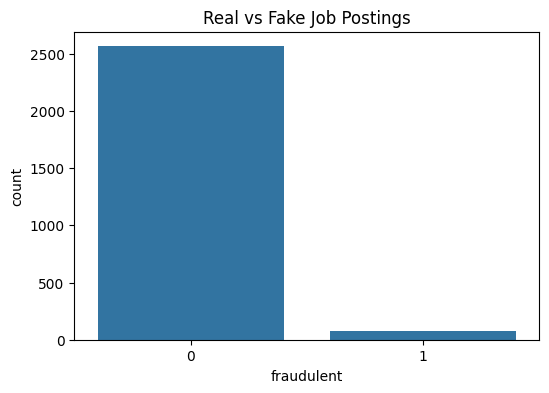

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df)
plt.title("Real vs Fake Job Postings")
plt.show()

Check Dataset Information

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2643 entries, 0 to 2642
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               2643 non-null   object
 1   title                2643 non-null   object
 2   location             2643 non-null   object
 3   department           2643 non-null   object
 4   salary_range         2643 non-null   object
 5   company_profile      2643 non-null   object
 6   description          2643 non-null   object
 7   requirements         2643 non-null   object
 8   benefits             2643 non-null   object
 9   telecommuting        2643 non-null   object
 10  has_company_logo     2643 non-null   object
 11  has_questions        2643 non-null   object
 12  employment_type      2643 non-null   object
 13  required_experience  2643 non-null   object
 14  required_education   2643 non-null   object
 15  industry             2643 non-null   object
 16  functi

Missing Values

In [19]:
df.isnull().sum()

,0
0,
job_id,0
title,0
location,0
department,0
salary_range,0
company_profile,0
description,0
requirements,0
benefits,0


Fill Missing Values

In [20]:
df=df.fillna(" ")

Check Target Classes

In [21]:
df['fraudulent'].value_counts()

,count
fraudulent,
0,2564
1,79


Plot Real vs Fake Jobs

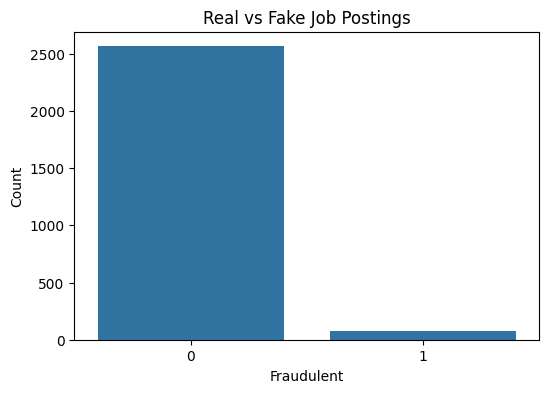

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='fraudulent', data=df)
plt.title("Real vs Fake Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.show()


Combine Text Columns

In [24]:
df['text'] = (
    df['title'].astype(str) + " " +
    df['company_profile'].astype(str) + " " +
    df['description'].astype(str) + " " +
    df['requirements'].astype(str) + " " +
    df['benefits'].astype(str)
)

Word Cloud

In [26]:
!pip install wordcloud

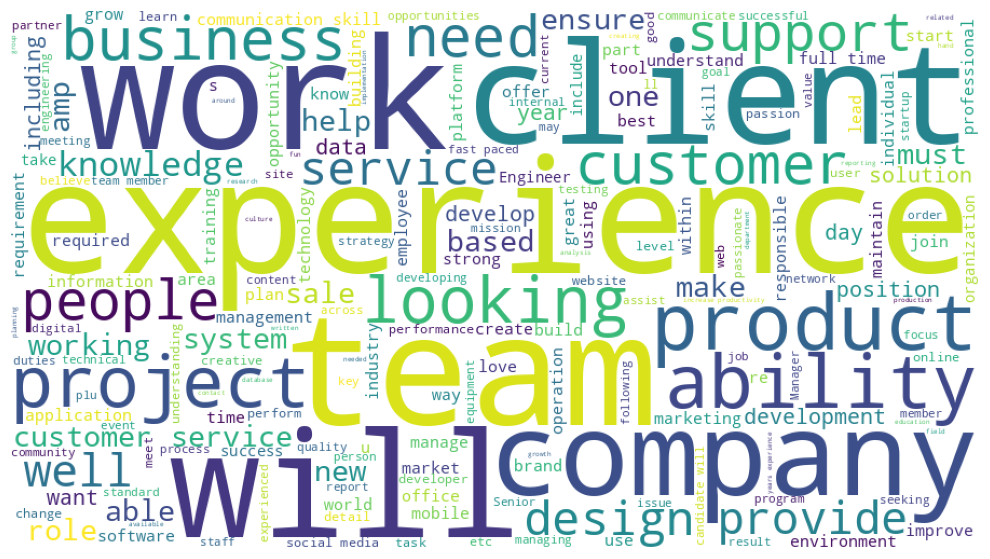

In [27]:
from wordcloud import WordCloud

text = " ".join(df['text'])

wordcloud = WordCloud(
    width=900,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Features and Labels

In [28]:
X = df['text']
y = df['fraudulent']

Train/Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Build and Train Model

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=10000)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, stop_words='english')),
                ('rf',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

Predict on Test Data

In [31]:
prediction = model.predict(X_test)

Accuracy

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, prediction)

print("Accuracy:", accuracy)

Accuracy: 0.9924385633270322


Classification Report

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       512
           1       1.00      0.76      0.87        17

    accuracy                           0.99       529
   macro avg       1.00      0.88      0.93       529
weighted avg       0.99      0.99      0.99       529



Confusion Matrix


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction)

print(cm)

[[512   0]
 [  4  13]]


Confusion Matrix Graph

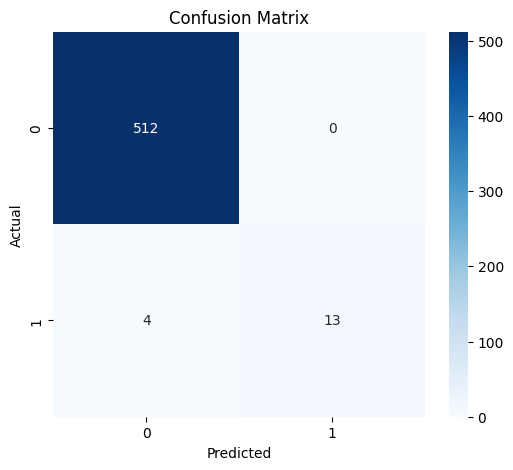

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Accuracy Bar Graph

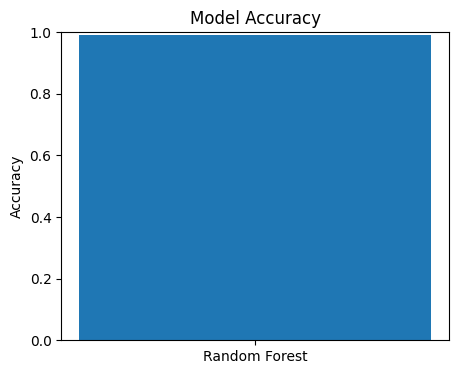

In [36]:
plt.figure(figsize=(5,4))

plt.bar(["Random Forest"], [accuracy])

plt.ylim(0,1)

plt.title("Model Accuracy")

plt.ylabel("Accuracy")

plt.show()

Save Model

In [37]:
import joblib

joblib.dump(model, "FakeJobModel.pkl")

print("Model Saved Successfully")

Model Saved Successfully


Download Model

In [38]:
from google.colab import files

files.download("FakeJobModel.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Test with a New Job Posting

In [40]:
sample = """
Urgently Hiring AI Engineer
Salary: $120000
Remote Job
Medical Insurance
Bachelor Degree Required
Python, Machine Learning, Deep Learning
"""
result = model.predict([sample])
if result[0] == '1' or result[0] == 1:
    print(" Fake Job Posting")
else:
    print("Real Job Posting")

Real Job Posting


Top 10 Industries

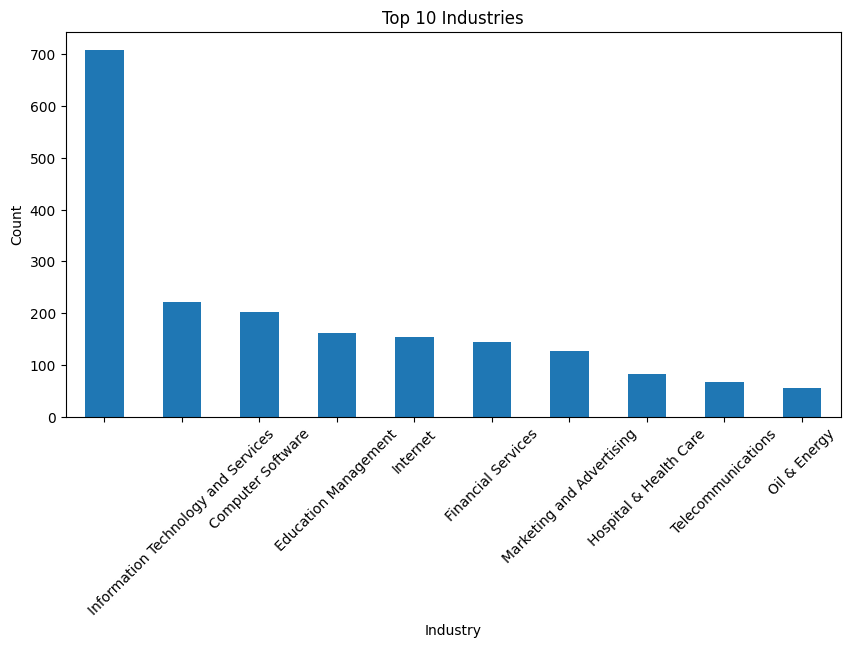

In [44]:
plt.figure(figsize=(10,5))
df['industry'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Industries")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Employment Types

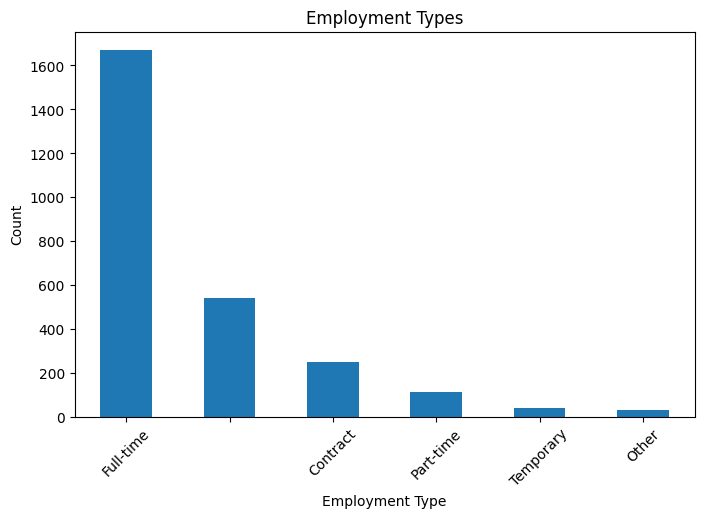

In [45]:
plt.figure(figsize=(8,5))
df['employment_type'].value_counts().plot(kind='bar')
plt.title("Employment Types")
plt.xlabel("Employment Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Required Education

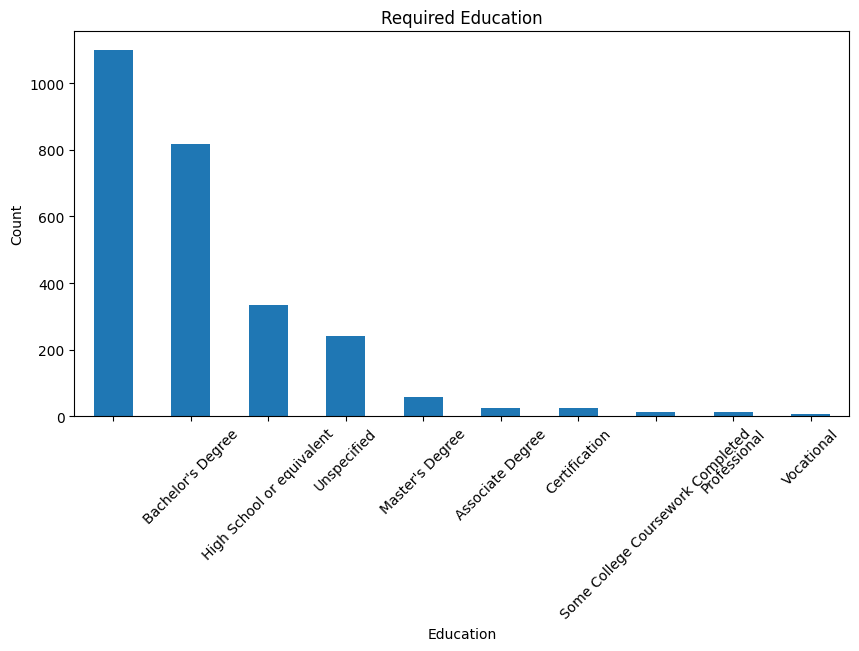

In [46]:
plt.figure(figsize=(10,5))
df['required_education'].value_counts().head(10).plot(kind='bar')
plt.title("Required Education")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Required Experience

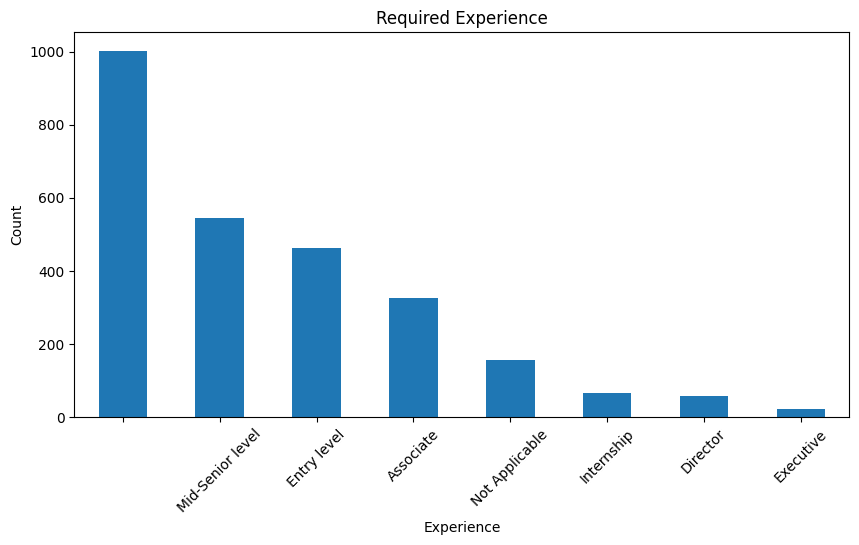

In [47]:
plt.figure(figsize=(10,5))
df['required_experience'].value_counts().head(10).plot(kind='bar')
plt.title("Required Experience")
plt.xlabel("Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Top Hiring Locations

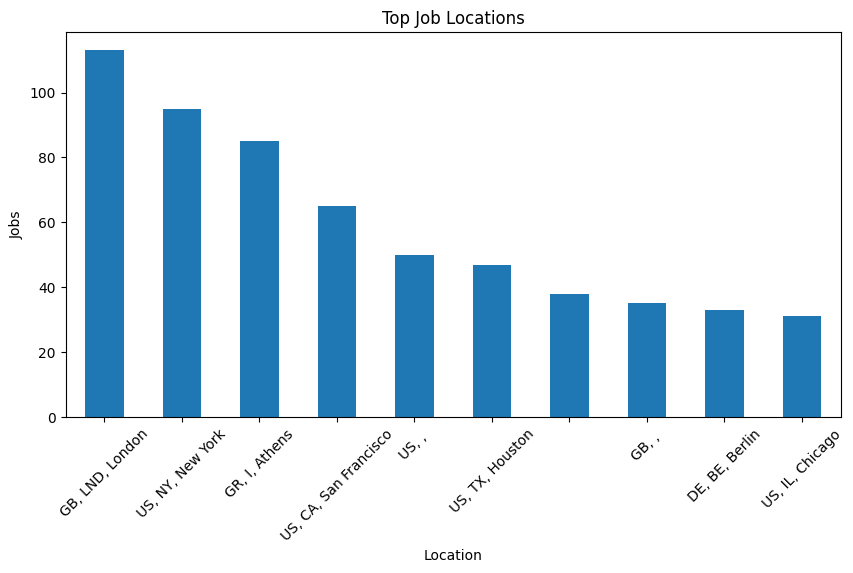

In [48]:
plt.figure(figsize=(10,5))
df['location'].value_counts().head(10).plot(kind='bar')
plt.title("Top Job Locations")
plt.xlabel("Location")
plt.ylabel("Jobs")
plt.xticks(rotation=45)
plt.show()

Pie Chart (Fake vs Real)

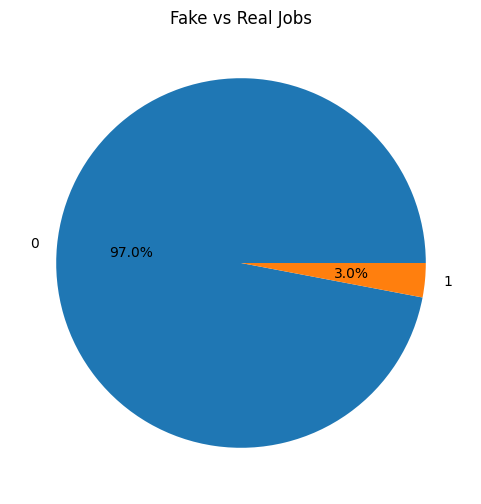

In [49]:
df['fraudulent'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Fake vs Real Jobs")
plt.ylabel("")
plt.show()

Final Results Cell

In [52]:
print("."*50)
print(" AI-Based Fake Job Posting Detection ")
print("."*50)

print(f"Dataset Shape : {df.shape}")
print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples : {len(X_test)}")
print(f"Accuracy : {accuracy*100:.2f}%")

print("\nModel : Random Forest Classifier")
print("Vectorizer : TF-IDF")
print("\nModel Training Completed Successfully!")

..................................................
 AI-Based Fake Job Posting Detection 
..................................................
Dataset Shape : (2643, 19)
Training Samples : 2114
Testing Samples : 529
Accuracy : 99.24%

Model : Random Forest Classifier
Vectorizer : TF-IDF

Model Training Completed Successfully!
